<a href="https://colab.research.google.com/github/TANUSHRI-BHISE/data_science_lab/blob/main/prac2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Create an “Academic performance” dataset of students and perform the following operations using
# Python.
# 1. Scan all variables for missing values and inconsistencies. If there are missing values and/or
# inconsistencies, use any of the suitable techniques to deal with them.
# 2. Scan all numeric variables for outliers. If there are outliers, use any of the suitable techniques
# to deal with them.
# 3. Apply data transformations on at least one of the variables. The purpose of this
# transformation should be one of the following reasons: to change the scale for better
# understanding of the variable, to convert a non-linear relation into a linear one, or to decrease
# the skewness and convert the distribution into a normal distribution.
# Reason and document your approach properly.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("StudentsPerformance.csv")
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [4]:
print(df.isnull().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [5]:
# df.loc[0:5, 'math score'] = np.nan
# df.loc[10:15, 'reading score'] = np.nan

In [6]:
# # Fill numeric columns with mean
# df['math score'] = df['math score'].fillna(df['math score'].mean())
# df['reading score'] = df['reading score'].fillna(df['reading score'].mean())

# # Fill categorical with mode
# df['lunch'] = df['lunch'].fillna(df['lunch'].mode()[0])

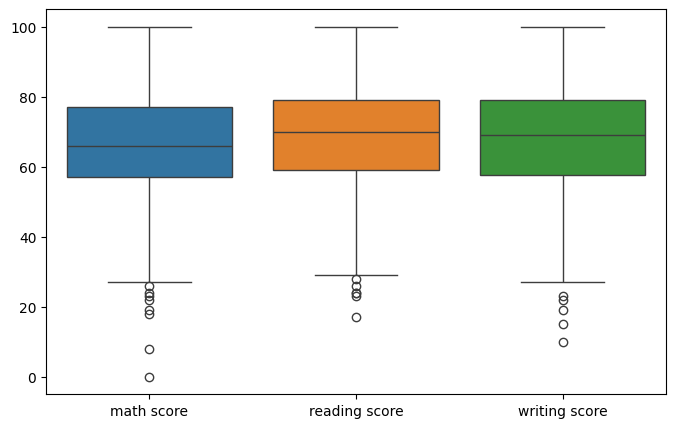

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['math score', 'reading score', 'writing score']])
plt.show()

In [8]:
Q1 = df['math score'].quantile(0.25)
Q3 = df['math score'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound:", lower)
print("Upper Bound:", upper)

Lower Bound: 27.0
Upper Bound: 107.0


In [9]:
df = df[(df['math score'] >= lower) & (df['math score'] <= upper)]

In [10]:
# Reading Score
Q1 = df['reading score'].quantile(0.25)
Q3 = df['reading score'].quantile(0.75)
IQR = Q3 - Q1
lower_read = Q1 - 1.5 * IQR
upper_read = Q3 + 1.5 * IQR

# Writing Score
Q1 = df['writing score'].quantile(0.25)
Q3 = df['writing score'].quantile(0.75)
IQR = Q3 - Q1
lower_write = Q1 - 1.5 * IQR
upper_write = Q3 + 1.5 * IQR

In [11]:
for col in ['math score', 'reading score', 'writing score']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

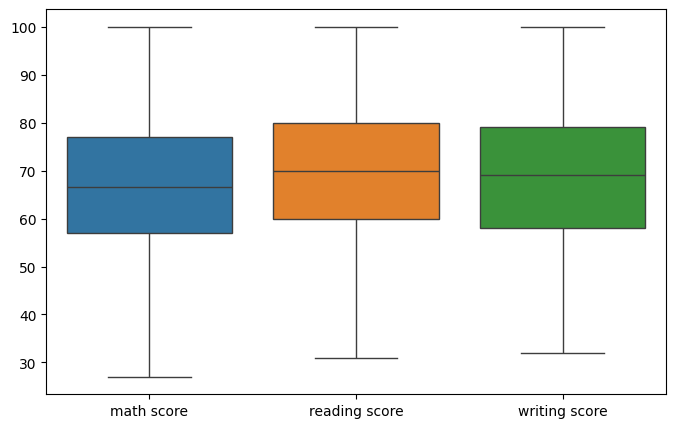

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['math score', 'reading score', 'writing score']])
plt.show()

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Apply on one column
df['math score'] = scaler.fit_transform(df[['math score']])

In [17]:
cols = ['math score', 'reading score', 'writing score']

df[cols] = scaler.fit_transform(df[cols])

<Axes: xlabel='math score', ylabel='Count'>

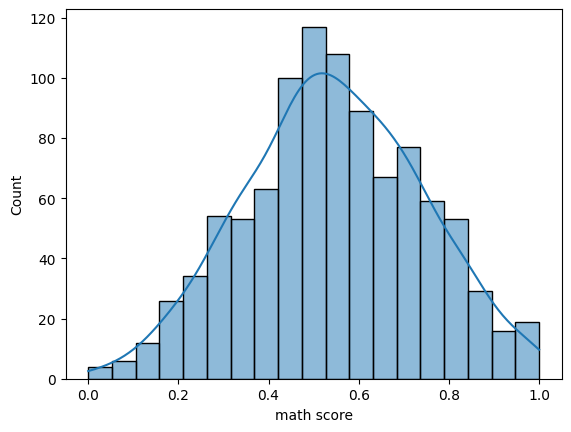

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['math score'], kde=True)
